#  Subset Asymmetry Distribution (With/Without Earth Contamination)

This notebook visualizes the distribution of asymmetry amplitudes ($R_C - R_O$) for planetary subsets, explicitly demonstrating the severe geometric contamination introduced by Earth's orbital perspective.

### Motivation
Due to the Rosenberg-Coleman mechanism and observational constraints, Earth is always situated on the "conjunction side" relative to any observable solar activity. Including Earth in the planetary subsets introduces a nearly +100% false positive artificial skew. 

To robustly investigate the true physical asymmetry caused by planetary conjunctions vs oppositions, we must strictly isolate and remove Earth from the analysis. This 2x2 multi-panel plot highlights this contrast:
- **Top Row (With Earth, 255 subsets)**: Demonstrates the massive artificial positive shift caused by geometric projection effects for both Flares and Sunspots.
- **Bottom Row (No Earth, 127 subsets)**: Represents the true underlying physical distributions. Removing Earth restores the Sunspot distribution to a symmetric null result (centered near 0), while revealing a genuine, persistent positive asymmetry enhancement specifically for Solar Flares.

### Data Inputs
* **With Earth**: `..._subset_scan_with_earth.csv`
* **Without Earth**: `..._subset_scan_no_earth.csv`
* **Condition**: Distributions are filtered strictly for **Window = 2**.


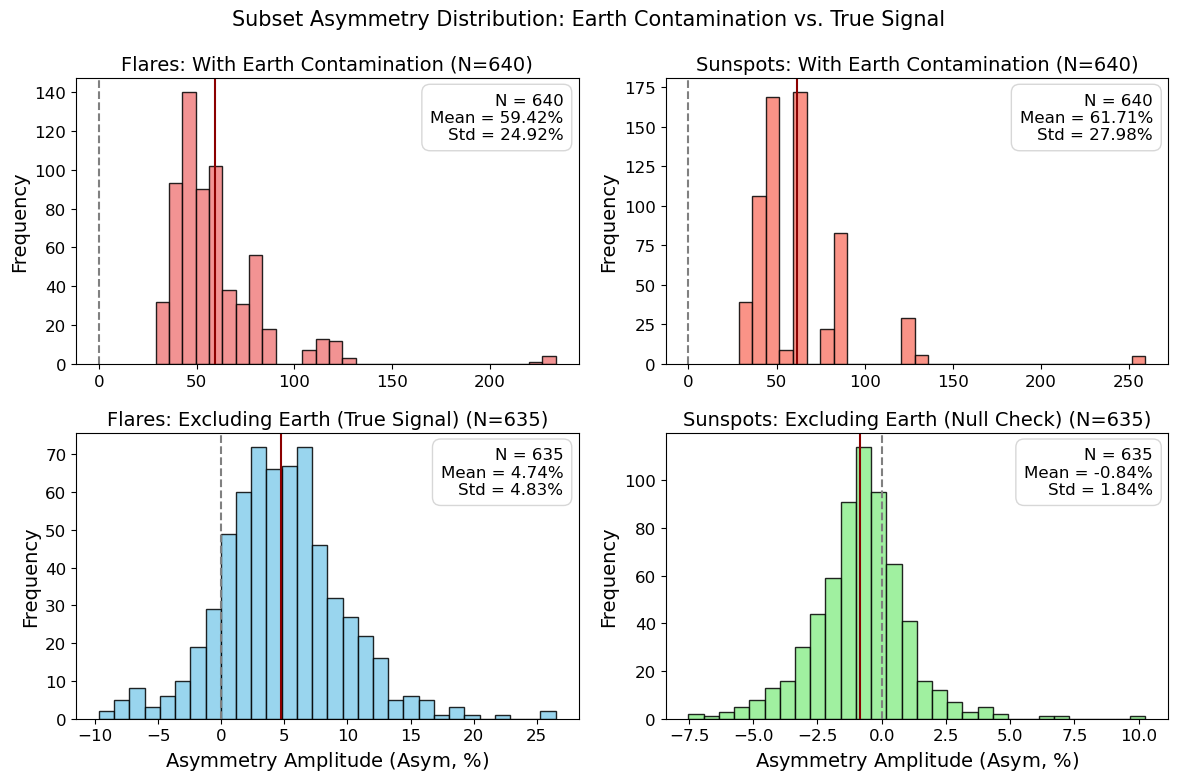

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configure matplotlib
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# ── 路径配置 ──────────────────────────────────────────────────────────────────
sf_with_path = '../../results/04_asymmetric/sf/sf_subset_scan_with_earth.csv'
sf_no_path   = '../../results/04_asymmetric/sf/sf_subset_scan_no_earth.csv'
sg_with_path = '../../results/04_asymmetric/sg/sg_subset_scan_with_earth.csv'
sg_no_path   = '../../results/04_asymmetric/sg/sg_subset_scan_no_earth.csv'
out_dir      = '../../results/04_asymmetric/'
os.makedirs(out_dir, exist_ok=True)

# ── 1. 读取数据 ───────────────────────────────────────────────────────────────
# 列名示例：Mask, Label, N_Planets, Has_Earth,
#           Conj_k_obs, Conj_k_exp, Conj_Ratio, Conj_p,
#           Opp_k_obs,  Opp_k_exp,  Opp_Ratio,  Opp_p,
#           Asym_Amp, Window
df_sf_with = pd.read_csv(sf_with_path)
df_sf_no   = pd.read_csv(sf_no_path)
df_sg_with = pd.read_csv(sg_with_path)
df_sg_no   = pd.read_csv(sg_no_path)

# 直接使用原始 Asym_Amp 列
asym_sf_with = df_sf_with['Asym_Amp']
asym_sf_no   = df_sf_no['Asym_Amp']
asym_sg_with = df_sg_with['Asym_Amp']
asym_sg_no   = df_sg_no['Asym_Amp']

# ── 2. 保存绘图坐标数据到 CSV ──────────────────────────────────────────────────
csv_rows = []
for label, df, asym in [
    ('SF_WithEarth', df_sf_with, asym_sf_with),
    ('SF_NoEarth',   df_sf_no,   asym_sf_no),
    ('SG_WithEarth', df_sg_with, asym_sg_with),
    ('SG_NoEarth',   df_sg_no,   asym_sg_no),
]:
    keep_cols = [c for c in ['Mask', 'Label', 'N_Planets', 'Conj_Ratio', 'Opp_Ratio', 'Asym_Amp', 'Conj_p', 'Opp_p', 'Window'] if c in df.columns]
    tmp = df[keep_cols].copy()
    tmp['Group'] = label
    csv_rows.append(tmp)

# csv_data = pd.concat(csv_rows, ignore_index=True)
# csv_path = os.path.join(out_dir, 'Fig05_plot_data.csv')
# csv_data.to_csv(csv_path, index=False)
# print(f"Plot data saved: {csv_path}")

# ── 3. 统计量（均值、std、n）──────────────────────────────────────────────────
stats_rows = []
for label, asym in [
    ('SF_WithEarth', asym_sf_with),
    ('SF_NoEarth',   asym_sf_no),
    ('SG_WithEarth', asym_sg_with),
    ('SG_NoEarth',   asym_sg_no),
]:
    stats_rows.append({
        'Group':  label,
        'N':      len(asym),
        'Mean':   round(asym.mean(), 4),
        'Std':    round(asym.std(),  4),
        'Median': round(asym.median(), 4),
        'Min':    round(asym.min(), 4),
        'Max':    round(asym.max(), 4),
    })
# pd.DataFrame(stats_rows).to_csv(os.path.join(out_dir, 'Fig05_stats.csv'), index=False)
# print(f"Stats saved: {out_dir}Fig05_stats.csv")

# ── 4. 辅助绘图函数 ───────────────────────────────────────────────────────────
def plot_hist(ax, asym_vals, title, color, include_x_label=False):
    n_count  = len(asym_vals)
    mean_val = asym_vals.mean()
    std_val  = asym_vals.std()

    ax.hist(asym_vals, bins=30, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(mean_val, color='darkred', linestyle='-', linewidth=1.5, label=f'Mean={mean_val:.2f}%')

    ax.text(0.97, 0.95,
            f'N = {n_count:,}\nMean = {mean_val:.2f}%\nStd = {std_val:.2f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=12,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray', boxstyle='round,pad=0.5'),
            zorder=10)

    ax.set_title(f"{title} (N={n_count:,})")
    ax.set_ylabel("Frequency")
    if include_x_label:
        ax.set_xlabel("Asymmetry Amplitude ($\\mathrm{Asym}$, %)")

# ── 5. 绘图 ───────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle("Subset Asymmetry Distribution: Earth Contamination vs. True Signal", fontsize=15)

# 顶排：含地球污染 (255 Subsets)
plot_hist(axs[0, 0], asym_sf_with, "Flares: With Earth Contamination",   'lightcoral')
plot_hist(axs[0, 1], asym_sg_with, "Sunspots: With Earth Contamination",  'salmon')

# 底排：剔除地球真实信号 (127 Subsets)
plot_hist(axs[1, 0], asym_sf_no, "Flares: Excluding Earth (True Signal)", 'skyblue',   include_x_label=True)
plot_hist(axs[1, 1], asym_sg_no, "Sunspots: Excluding Earth (Null Check)",'lightgreen',include_x_label=True)

plt.tight_layout()

# ── 6. 保存图形 ───────────────────────────────────────────────────────────────
# fig_out_base = os.path.join(out_dir, 'Fig05_subset_asym_earth_comparison')
# plt.savefig(f'{fig_out_base}.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig(f'{fig_out_base}.eps', format='eps', bbox_inches='tight')
# print(f"Figures successfully saved to: {out_dir}")

plt.show()
